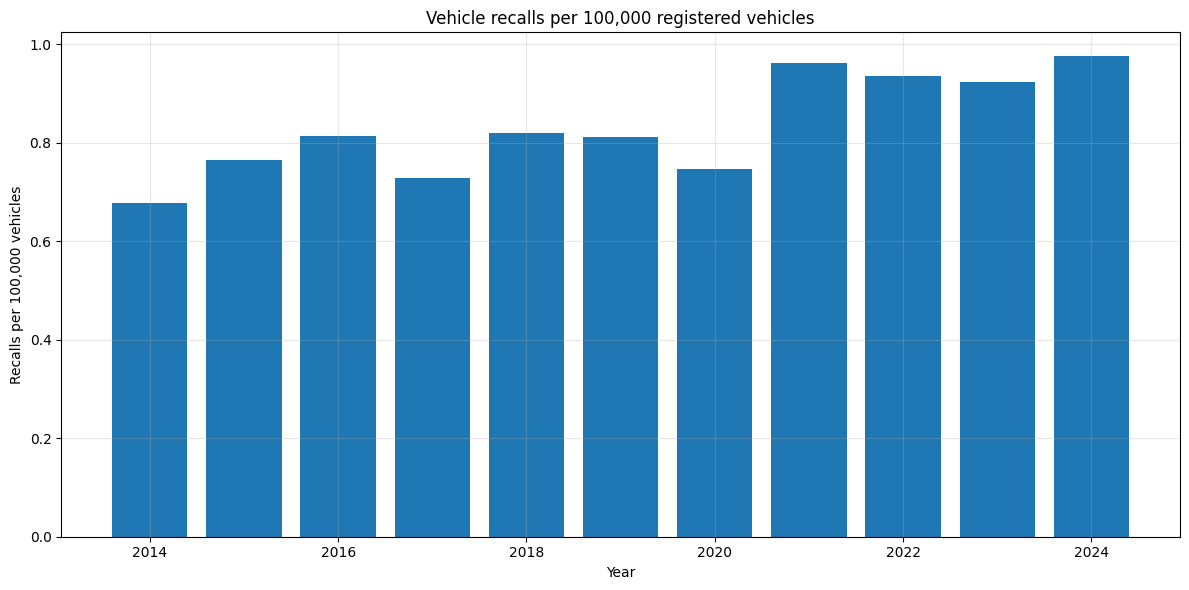

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

recalls = pd.read_csv("data/Recalls_Data.csv")

recalls = recalls.loc[
    recalls["Recall Type"].str.strip().eq("Vehicle")
].copy()

recalls["Report Received Date"] = pd.to_datetime(
    recalls["Report Received Date"],
    errors="coerce"
)

recalls["Year"] = recalls["Report Received Date"].dt.year

recall_yearly = (
    recalls.groupby("Year")
    .size()
    .reset_index(name="recalls")
)


vehicles = pd.read_csv("data/Motor_Vehicle_Registrations__1900_-_2024__MV-1_.csv")

vehicles = vehicles.loc[
    vehicles["Category"].str.strip().eq("Auto")
].copy()

vehicles["Vehicles"] = pd.to_numeric(
    vehicles["Vehicles"],
    errors="coerce"
)

vehicle_yearly = (
    vehicles.groupby("Year")["Vehicles"]
    .sum()
    .reset_index()
)


yearly = recall_yearly.merge(
    vehicle_yearly,
    on="Year",
    how="inner"
)

yearly["recalls_per_100k_vehicles"] = (
    yearly["recalls"] /
    yearly["Vehicles"] *
    100000
)

yearly = yearly[(yearly["Year"] >= 2014) & (yearly["Year"] <= 2024)]

plt.figure(figsize=(12, 6))

plt.bar(
    yearly["Year"],
    yearly["recalls_per_100k_vehicles"],
    #marker="o"
)

plt.title("Vehicle recalls per 100,000 registered vehicles")
plt.xlabel("Year")
plt.ylabel("Recalls per 100,000 vehicles")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
yearly

,Year,recalls,Vehicles,recalls_per_100k_vehicles
48,2014,771,113898844.0,0.676916
49,2015,863,112864228.0,0.764636
50,2016,919,112961266.0,0.813553
51,2017,810,111177029.0,0.728568
52,2018,911,111242132.0,0.818934
53,2019,880,108547707.0,0.810703
54,2020,784,105135300.0,0.745706
55,2021,987,102724349.0,0.960824
56,2022,932,99666377.0,0.935120
57,2023,894,96901565.0,0.922586
